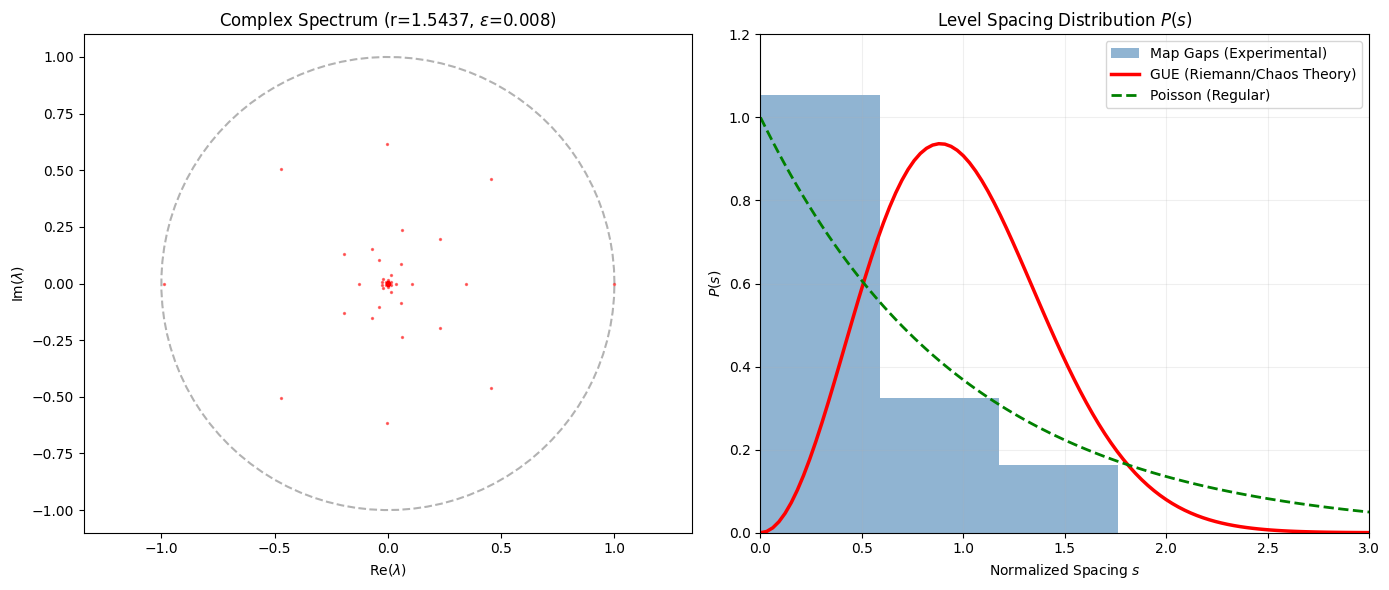

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 实验参数设置
# ==========================================
r = 1.5437       # 选用你指定的 Misiurewicz 点
N = 10000         # 空间划分格子数 (Ulam 方法)
epsilon = 0.008  # 加入微小扰动，显现谱结构
n_top = 4000      # 参与间距统计的特征值数量

# ==========================================
# 2. 构造转移矩阵 (Ulam's Method)
# ==========================================
edges = np.linspace(-1, 1, N + 1)
centers = (edges[:-1] + edges[1:]) / 2
P = np.zeros((N, N))

for j in range(N):
    # 确定性映射: x_{n+1} = 1 - r * x_n^2
    x_next = 1 - r * (centers[j]**2)
    
    # 模拟真实物理环境中的高斯扰动 (扩散算子)
    dist = np.abs(centers - x_next)
    kernel = np.exp(-dist**2 / (2 * epsilon**2))
    P[:, j] = kernel / kernel.sum() # 保证概率守恒

# ==========================================
# 3. 提取特征值与“谱展开” (Unfolding)
# ==========================================
eigvals = np.linalg.eigvals(P)
mags = np.abs(eigvals)

# 过滤：去掉稳态(1.0)和底部的数值噪声，只留中间的“冰山”部分
mags_filtered = np.sort(mags[(mags > 0.05) & (mags < 0.99)])

# 计算相邻间距 (Gap)
spacings = np.diff(mags_filtered)

# 核心：均值归一化 (让样本数不敏感，平均间距为 1)
s = spacings / np.mean(spacings)

# ==========================================
# 4. 绘图对比：见证混沌指纹 (已修复 SyntaxWarning)
# ==========================================
plt.figure(figsize=(14, 6))

# --- 左图：复平面特征值分布 ---
plt.subplot(1, 2, 1)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)
plt.scatter(eigvals.real, eigvals.imag, s=2, c='red', alpha=0.5)

# 使用 rf 前缀解决 LaTeX 转义警告
plt.title(rf"Complex Spectrum (r={r}, $\epsilon$={epsilon})") 
plt.xlabel(r"Re($\lambda$)")
plt.ylabel(r"Im($\lambda$)")
plt.axis('equal')

# --- 右图：间距分布 P(s) 对比 ---
plt.subplot(1, 2, 2)
# 绘制动力学系统的间距直方图
bins = min(50, np.histogram_bin_edges(s, bins='fd').size)
plt.hist(s, bins=bins, density=True, alpha=0.6, color='steelblue', label='Map Gaps (Experimental)')

# 绘制 GUE 理论曲线 (黎曼零点 / 强混沌统计)
x_plot = np.linspace(0, 3, 100)
gue = (32 / (np.pi**2)) * (x_plot**2) * np.exp(-(4 / np.pi) * (x_plot**2))
plt.plot(x_plot, gue, 'r-', lw=2.5, label='GUE (Riemann/Chaos Theory)')

# 绘制 Poisson 曲线 (规则系统/无排斥)
plt.plot(x_plot, np.exp(-x_plot), 'g--', lw=2, label='Poisson (Regular)')

plt.title(r"Level Spacing Distribution $P(s)$")
plt.xlabel(r"Normalized Spacing $s$")
plt.ylabel(r"$P(s)$")
plt.xlim(0, 3)
plt.ylim(0, 1.2)
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()